<a href="https://colab.research.google.com/github/RSPatQ6IBI/signal_processing_labs.github.io/blob/main/tutorials_/the_random_forest_tutorial_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest 🪵🪵🌲🌲🌳🌲🌲🪵🪵
#  🐶[CREDITS](https://mlu-explain.github.io/random-forest/)

#[AWESOME REPO](https://github.com/kjw0612/awesome-random-forest?tab=readme-ov-file)
<hr>

### Condorcet's Jury Theorem says that if each person is more than 50% correct, then adding more people to vote increases the probability that the majority is correct.
<hr>

<img src="https://miro.medium.com/v2/1*XzaoQxMf4uLD5DIHz8JwbA.png" alt="ENSEMBLE LEARNING, AND BOOSTING" width="600" height="300">


#### In machine learning, this concept of multiple models working together to come to an aggregate prediction is called ensemble learning. It provides the basis for many important machine learning models, including random forests.


# 🤔
- `Random Forest` is an ensemble of `Decision Trees`
- A `RandomForestClassifier` comprise of hyperparameters of a `DecisionTreeClassifier` (to control how trees are grown), and `BaggingClassifier` (for controlling ensemble behavior)


- **Bagging Method** - a `sampling method` to create multiple samples from the training data to build multiple trees in random forests.

- randomly draws a fixed number of samples from the training set with replacement. This means that a data point can be drawn more than once.

- another way of splitting uses only a randomly selected subset of the features, hence ensuring that the decision trees are as different as possible.


## The Random Forest algorithm
- introduces extra randomness when growing trees
- instead of searching for the very best feature when splitting a node, it searches for the best feature among a random subset of features.

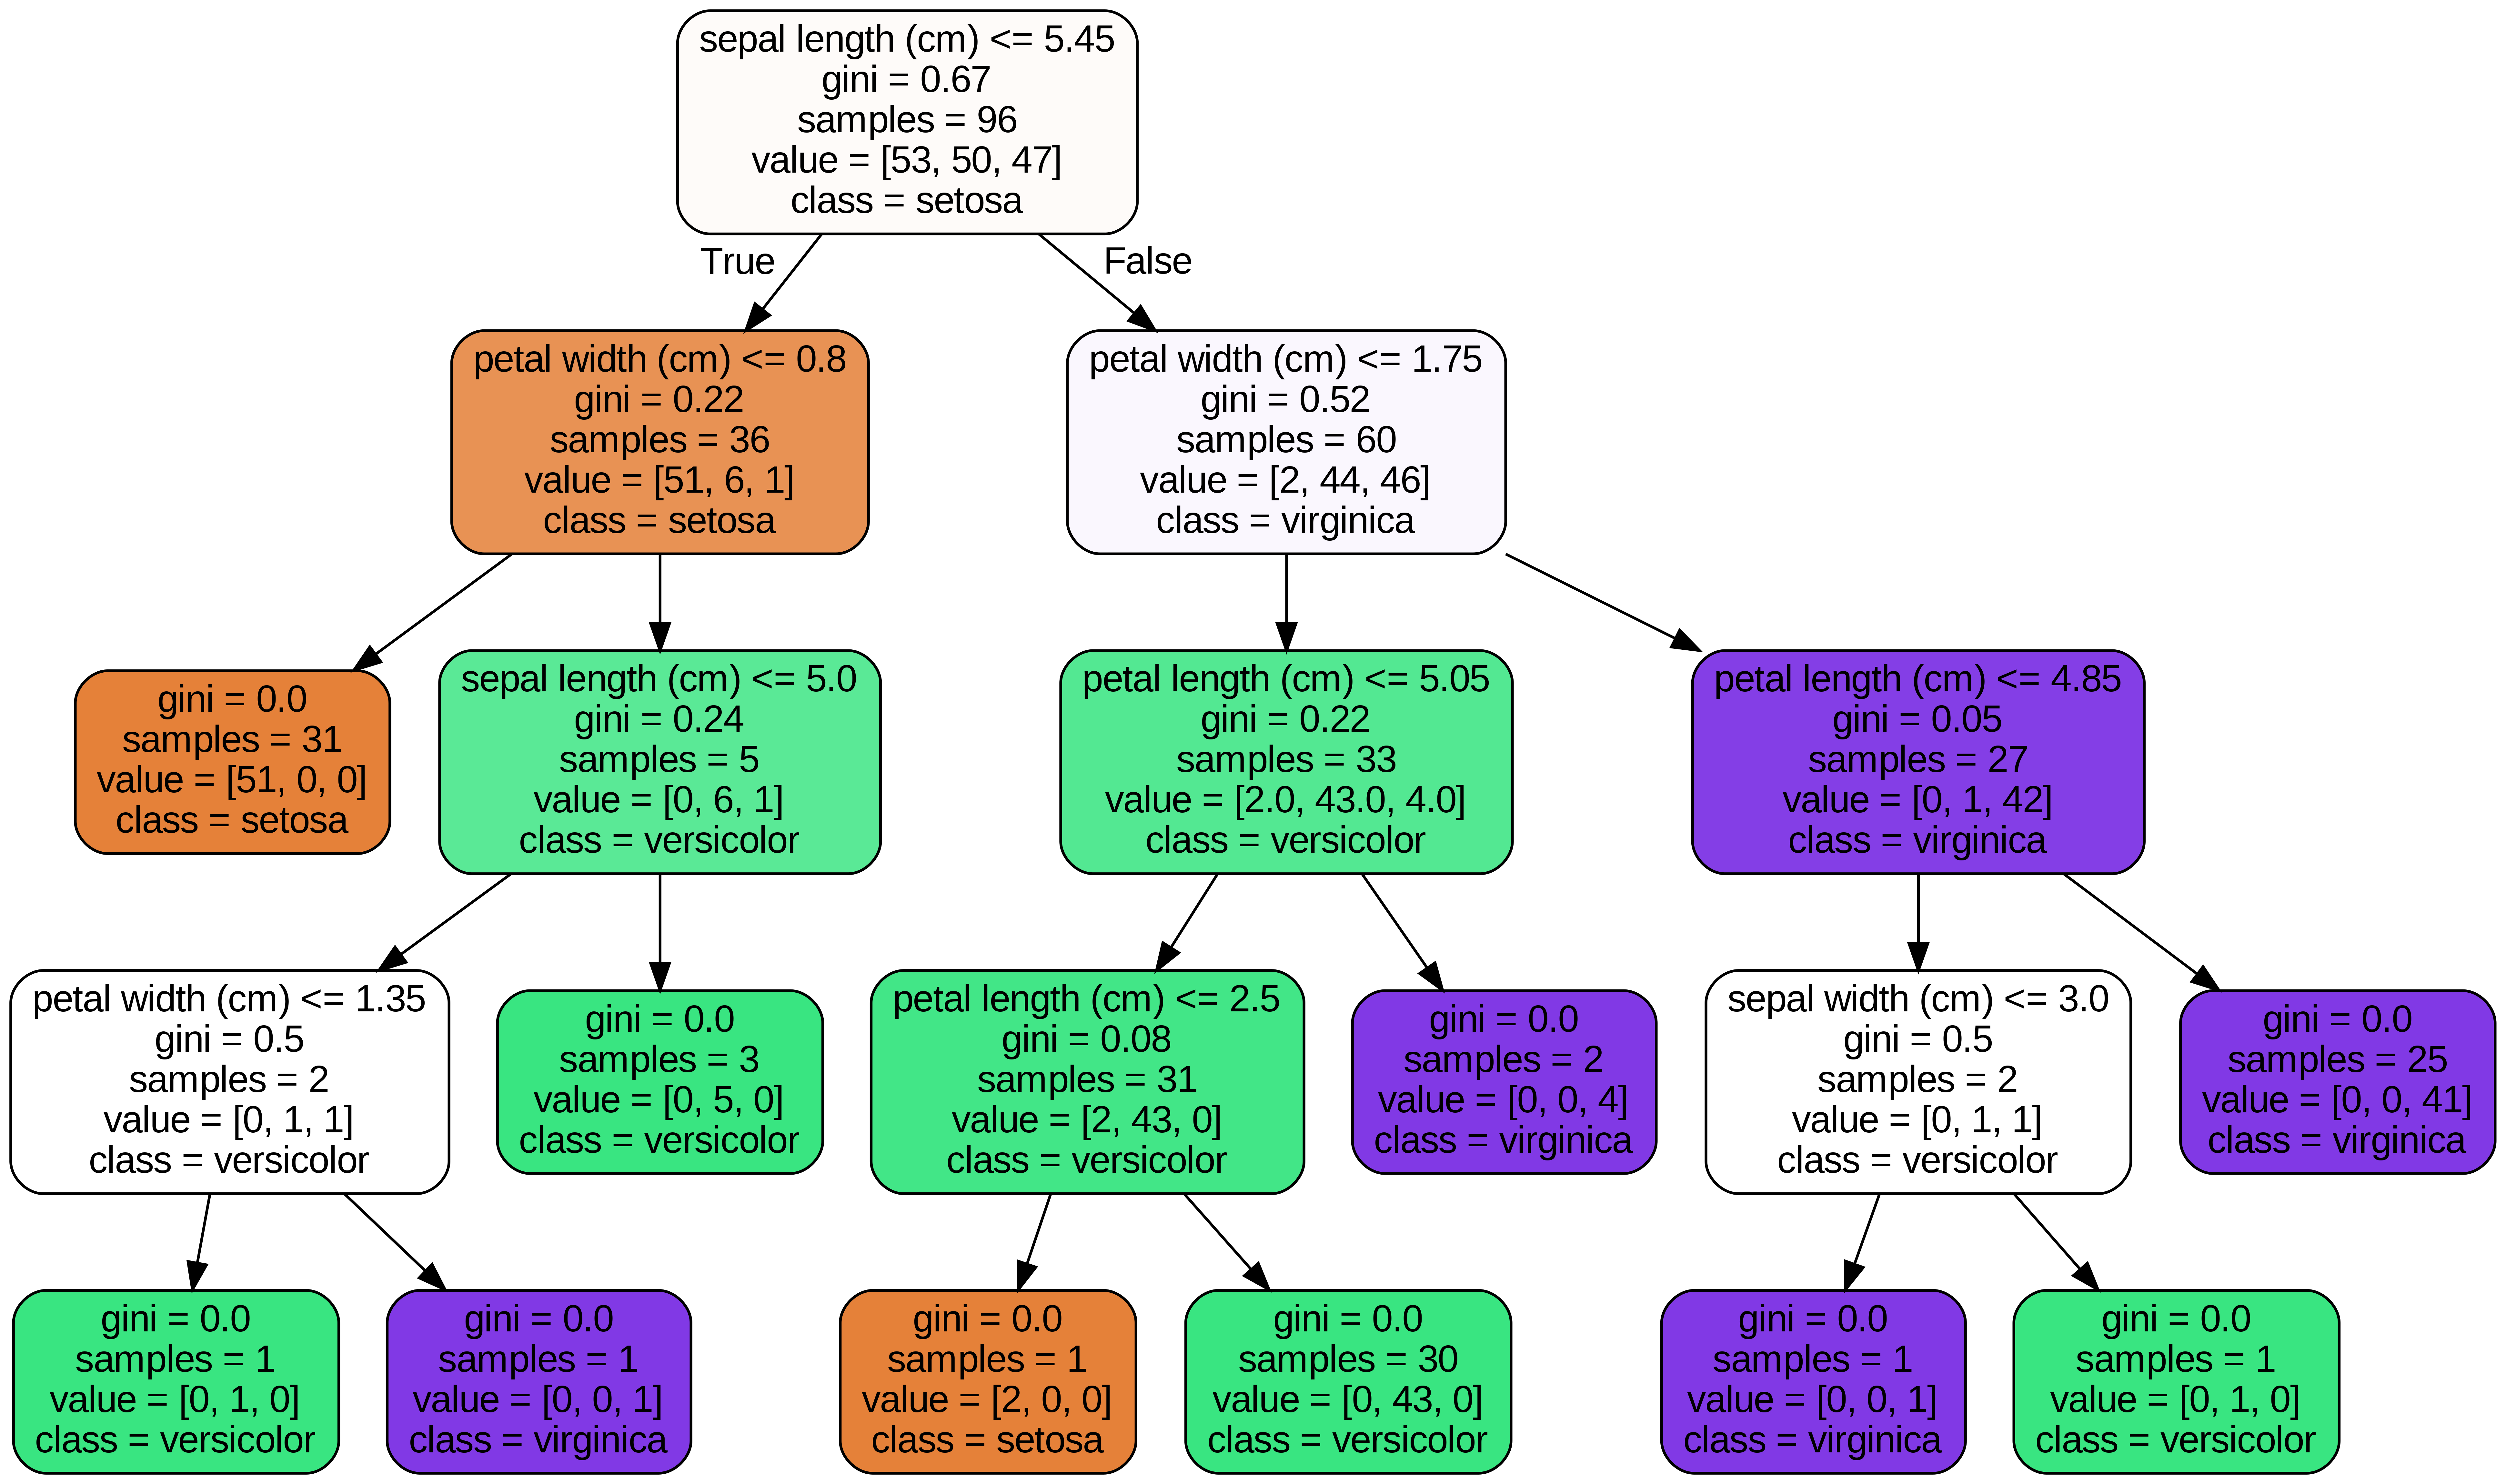

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()

# Model (can also use single decision tree)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=10)

# Train
model.fit(iris.data, iris.target)
# Extract single tree
estimator = model.estimators_[5]

from sklearn.tree import export_graphviz
# Export as dot file
export_graphviz(estimator, out_file='tree.dot',
                feature_names = iris.feature_names,
                class_names = iris.target_names,
                rounded = True, proportion = False,
                precision = 2, filled = True)

# Convert to png using system command (requires Graphviz)
from subprocess import call
call(['dot', '-Tpng', 'tree.dot', '-o', 'tree.png', '-Gdpi=600'])

# Display in jupyter notebook
from IPython.display import Image
Image(filename = 'tree.png', width=800, height=700)

In [ ]:
!pip install -q rasterio rasterstats geopandas treeinterpreter scikit-learn
output.clear()
print('Installed Raterio , Rasterstats, Geopandas, TreeInterpreter and Scikit-Learn')

Installed Raterio , Rasterstats, Geopandas, TreeInterpreter and Scikit-Learn


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio

from rasterio.features import rasterize
from rasterstats.io import bounds_window
import rasterstats
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from treeinterpreter import treeinterpreter as ti
from os import path as op
import pickle


# read in training data
training_vectors = gpd.read_file('training_data.geojson')
training_vectors.head()